In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

def run_bot_iot_pipeline_v10(file_paths):
    print("Step 1: Reading random samples from files...")
    list_df = []
    for f in file_paths:
        try:
            temp_df = pd.read_csv(f, low_memory=False).sample(frac=0.1, random_state=42)
            list_df.append(temp_df)
            print(f"Sample loaded from: {f}")
        except Exception as e:
            print(f"Error: {e}")

    df_all = pd.concat(list_df, ignore_index=True)
    df_all = df_all.dropna()

    target_col = 'label' if 'label' in df_all.columns else 'category'

    encoders = {}
    for col in df_all.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        df_all[col] = le.fit_transform(df_all[col].astype(str))
        encoders[col] = le

    drop_cols = [target_col, 'attack', 'category', 'subcategory', 'pkSeqID', 'stime', 'ltime']
    X = df_all.drop(columns=[c for c in drop_cols if c in df_all.columns], errors='ignore')
    y = df_all[target_col]

    print("Step 2: Splitting data (80/20)...")
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print("Step 3: Selecting top 10 features...")
    selector = SelectKBest(score_func=f_classif, k=10)
    X_train_selected = selector.fit_transform(X_train_raw, y_train)
    X_test_selected = selector.transform(X_test_raw)

    selected_features = X.columns[selector.get_support()].tolist()
    print(f"The 10 selected features are: \n{selected_features}")

    scaler = StandardScaler()
    X_train_final = scaler.fit_transform(X_train_selected)
    X_test_final = scaler.transform(X_test_selected)

    print("\nPhase 2 completed with 10 features!")
    return {
        "X_train": X_train_final, "y_train": y_train,
        "X_test": X_test_final, "y_test": y_test,
        "feature_names": selected_features,
        "encoders": encoders,
        "selector": selector,
        "scaler": scaler
    }

my_files = ["/content/reduced_data_1.csv", "/content/reduced_data_2.csv"]
data = run_bot_iot_pipeline_v10(my_files)

Step 1: Reading random samples from files...
Sample loaded from: /content/reduced_data_1.csv
Sample loaded from: /content/reduced_data_2.csv
Step 2: Splitting data (80/20)...
Step 3: Selecting top 10 features...
The 10 selected features are: 
['proto', 'proto_number', 'daddr', 'state', 'dur', 'sum', 'TnP_PSrcIP', 'TnP_PerProto', 'TnP_Per_Dport', 'Pkts_P_State_P_Protocol_P_SrcIP']

Phase 2 completed with 10 features!


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Starting training on 10 features...

Random Forest        | Accuracy: 0.9996 | Time: 11.14s
Logistic Regression  | Accuracy: 0.9586 | Time: 2.17s
SVM (Linear)         | Accuracy: 0.9611 | Time: 0.47s


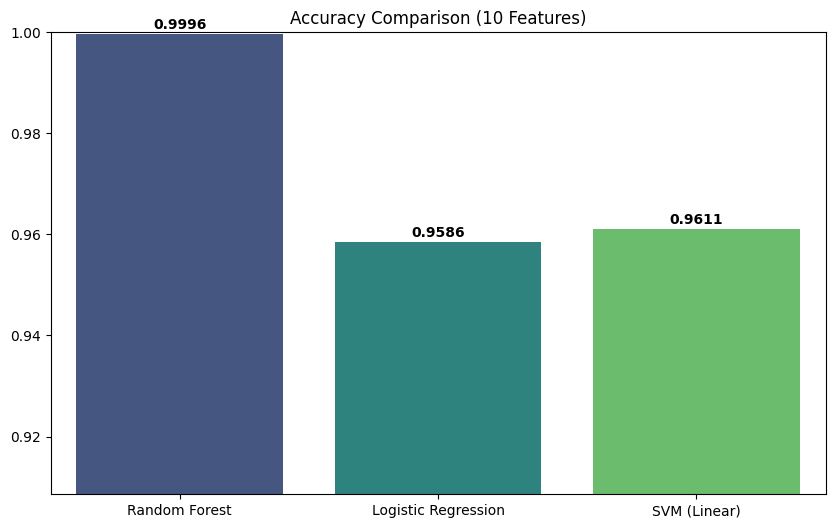

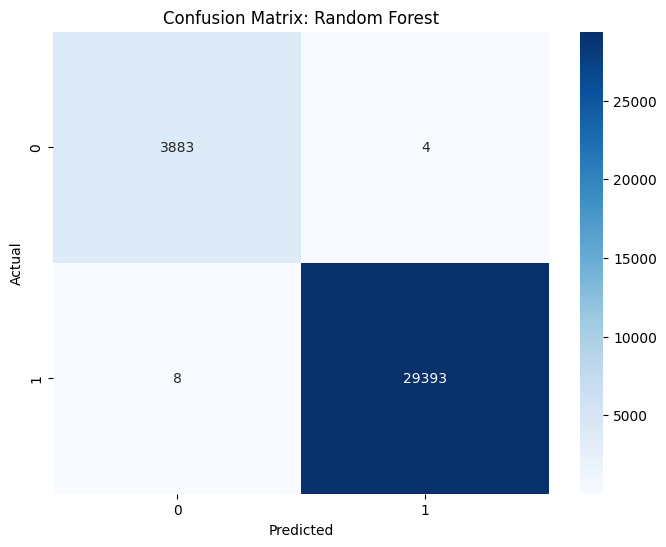


The best model based on accuracy is: Random Forest

Models and preprocessing objects saved successfully to Google Drive!


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
import os
from google.colab import drive

def run_training_v10(data_dict):
    X_train, y_train = data_dict['X_train'], data_dict['y_train']
    X_test, y_test = data_dict['X_test'], data_dict['y_test']

    models = {
        "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
        "Logistic Regression": LogisticRegression(max_iter=2000),
        "SVM (Linear)": LinearSVC(dual=False, random_state=42)
    }

    results = {}
    trained_models = {}
    print("Starting training on 10 features...\n")

    for name, model in models.items():
        start = time.time()
        model.fit(X_train, y_train)
        end = time.time()

        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        results[name] = {
            "Accuracy": acc,
            "Time": round(end - start, 2),
            "Report": classification_report(y_test, y_pred),
            "Matrix": confusion_matrix(y_test, y_pred)
        }
        trained_models[name] = model
        print(f"{name:20} | Accuracy: {acc:.4f} | Time: {results[name]['Time']}s")

    plt.figure(figsize=(10, 6))
    model_names = list(results.keys())
    accuracies = [results[n]['Accuracy'] for n in model_names]

    sns.barplot(x=model_names, y=accuracies, hue=model_names, palette='viridis', legend=False)

    plt.title('Accuracy Comparison (10 Features)')
    plt.ylim(min(accuracies) - 0.05, 1.0)
    for i, v in enumerate(accuracies):
        plt.text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')
    plt.show()

    best_name = max(results, key=lambda x: results[x]['Accuracy'])
    plt.figure(figsize=(8, 6))
    sns.heatmap(results[best_name]['Matrix'], annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {best_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print(f"\nThe best model based on accuracy is: {best_name}")

    if not os.path.exists('/content/drive/MyDrive'):
        print("\nMounting Google Drive...")
        drive.mount('/content/drive')

    joblib.dump(trained_models["Random Forest"], '/content/drive/MyDrive/rf_model.pkl')
    joblib.dump(trained_models["Logistic Regression"], '/content/drive/MyDrive/lr_model.pkl')
    joblib.dump(trained_models["SVM (Linear)"], '/content/drive/MyDrive/svm_model.pkl')
    joblib.dump(data_dict['scaler'], '/content/drive/MyDrive/scaler.pkl')
    joblib.dump(data_dict['selector'], '/content/drive/MyDrive/selector.pkl')
    joblib.dump(data_dict['encoders'], '/content/drive/MyDrive/label_encoders_dict.pkl')

    print("\nModels and preprocessing objects saved successfully to Google Drive!")
    return results

final_results = run_training_v10(data)